# Model pricing baseline: error analysis

Этот notebook завершает MVP baseline-анализ для курсовой. Предыдущий шаг уже дал нам модельные цены `Black-76` с двумя историческими оценками волатильности: `hv_21d` и `hv_63d`. Теперь задача - разобрать ошибки модели как исследовательский результат: понять, в каких рыночных состояниях baseline работает лучше, а где ломается.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
project_root = Path('/Users/maria/Desktop/Code/HSE/COURSEBOOK')
input_path = project_root / 'results/model_pricing_baseline.parquet'
results_dir = project_root / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(input_path)
df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'], errors='coerce')
df['option_type_analysis'] = df['option_type_norm'] if 'option_type_norm' in df.columns else df['option_type']

df['moneyness_bucket_analysis'] = pd.cut(
    df['moneyness'],
    bins=[0, 0.9, 0.97, 1.03, 1.1, np.inf],
    labels=['deep_OTM', 'OTM', 'ATM', 'ITM', 'deep_ITM'],
)

df['DTE_bucket_analysis'] = pd.cut(
    df['DTE_DAYS'],
    bins=[0, 7, 30, 90, np.inf],
    labels=['0-7', '8-30', '31-90', '91+'],
)

sigma_variants = ['hv_21d', 'hv_63d']
df.shape

(19327, 53)

## Цель анализа ошибок

В этом разделе мы считаем **рыночную цену** (`market_price`) эталоном, а **модельную цену** (`model_price`) - приближением. Разница между ними показывает, насколько хорошо baseline-модель описывает наблюдаемый рынок.

Логика простая:
- если ошибка маленькая, модель адекватно воспроизводит рынок;
- если ошибка растёт в определённых режимах или сегментах поверхности, значит именно там baseline начинает терять качество;
- сравнение `hv_21d` и `hv_63d` показывает, какой способ задания volatility input лучше работает в нашей задаче.

In [3]:
def calc_error_metrics(frame, sigma_col):
    sub = frame.loc[frame[f'model_price_{sigma_col}'].notna()].copy()
    if sub.empty:
        return pd.Series(
            {
                'N': 0,
                'MAE': np.nan,
                'RMSE': np.nan,
                'mean_error': np.nan,
                'median_abs_error': np.nan,
                'mean_pct_error': np.nan,
            }
        )

    return pd.Series(
        {
            'N': int(len(sub)),
            'MAE': float(sub[f'abs_error_{sigma_col}'].mean()),
            'RMSE': float(np.sqrt(sub[f'squared_error_{sigma_col}'].mean())),
            'mean_error': float(sub[f'error_{sigma_col}'].mean()),
            'median_abs_error': float(sub[f'abs_error_{sigma_col}'].median()),
            'mean_pct_error': float(sub[f'pct_error_{sigma_col}'].mean()),
        }
    )


def summarize_by_group(frame, group_col):
    parts = []
    values = frame[group_col].drop_duplicates().tolist()
    if frame[group_col].isna().any():
        values.append(np.nan)

    seen = set()
    for value in values:
        key = '__nan__' if pd.isna(value) else str(value)
        if key in seen:
            continue
        seen.add(key)

        if pd.isna(value):
            subset = frame.loc[frame[group_col].isna()]
            label = 'NaN'
        else:
            subset = frame.loc[frame[group_col] == value]
            label = value

        row = {'slice_value': label}
        for sigma_col in sigma_variants:
            metrics = calc_error_metrics(subset, sigma_col)
            for metric_name, metric_value in metrics.items():
                row[f'{metric_name}_{sigma_col}'] = metric_value
        parts.append(row)

    return pd.DataFrame(parts)

## Overall error comparison

Сначала сравним обе версии volatility input на всей доступной выборке. Это самый простой способ понять, какой baseline в среднем точнее: `Black-76 + hv_21d` или `Black-76 + hv_63d`.

In [4]:
overall_metrics = pd.DataFrame({sigma_col: calc_error_metrics(df, sigma_col) for sigma_col in sigma_variants}).T
overall_metrics.index.name = 'sigma_variant'
overall_metrics = overall_metrics.reset_index()
overall_metrics

,sigma_variant,N,MAE,RMSE,mean_error,median_abs_error,mean_pct_error
0,hv_21d,18926.0,326.288671,452.591519,-309.581680,216.694544,3.418021
1,hv_63d,18077.0,308.996963,435.453098,-292.995101,192.985502,2.875946


**Интерпретация.** В текущем baseline `hv_63d` выглядит немного лучше, чем `hv_21d`: у него ниже `MAE`, ниже `RMSE` и ниже медианная абсолютная ошибка. Это логично для спокойного baseline: более длинное historical volatility window даёт более сглаженный volatility input и уменьшает шум.

## Error by volatility regime

Теперь проверим, как меняются ошибки в разных volatility regimes. Если baseline работает хуже в `high_vol`, это будет важным аргументом в пользу более адаптивных volatility-моделей.

In [5]:
vol_regime_metrics = summarize_by_group(df, 'vol_regime')
vol_regime_metrics

,slice_value,N_hv_21d,MAE_hv_21d,RMSE_hv_21d,mean_error_hv_21d,median_abs_error_hv_21d,mean_pct_error_hv_21d,N_hv_63d,MAE_hv_63d,RMSE_hv_63d,mean_error_hv_63d,median_abs_error_hv_63d,mean_pct_error_hv_63d
0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1,low_vol,7224.0,233.974027,378.351753,-232.137907,99.998651,-0.701591,6375.0,170.856017,291.767105,-165.913241,82.841849,-0.602488
2,mid_vol,5878.0,371.015878,487.816338,-361.719571,359.837666,0.783727,5878.0,357.617061,472.715459,-338.736245,330.735397,2.041998
3,high_vol,5824.0,395.652421,497.920049,-353.020433,380.587398,11.186643,5824.0,411.136318,519.463432,-385.934731,416.432813,7.525149


**Интерпретация.** Ошибки действительно растут в `high_vol` regime. Для обеих версий volatility input `MAE` и `RMSE` выше в стрессовых волатильных состояниях, чем в `low_vol`. Значит простой `Black-76 + historical volatility` хуже справляется именно там, где рынок наиболее нестабилен.

## Error by trend regime and combined market state

Помимо уровня волатильности, полезно проверить и направление рынка. Для этого сравним ошибки по `trend_regime`, а затем посмотрим на более подробный `regime_label`, который объединяет волатильность и тренд.

In [6]:
trend_regime_metrics = summarize_by_group(df, 'trend_regime')
regime_label_metrics = summarize_by_group(df, 'regime_label')

print('By trend_regime')
display(trend_regime_metrics)
print('\nBy regime_label')
display(regime_label_metrics)

By trend_regime


,slice_value,N_hv_21d,MAE_hv_21d,RMSE_hv_21d,mean_error_hv_21d,median_abs_error_hv_21d,mean_pct_error_hv_21d,N_hv_63d,MAE_hv_63d,RMSE_hv_63d,mean_error_hv_63d,median_abs_error_hv_63d,mean_pct_error_hv_63d
0,down,10057.0,324.503247,455.311632,-304.811112,214.437239,6.163712,9996.0,324.148526,456.688395,-306.733450,219.204674,4.141380
1,up,8869.0,328.313253,449.487132,-314.991264,218.377077,0.304545,8081.0,290.254850,407.657987,-276.001097,174.142888,1.310635



By regime_label


,slice_value,N_hv_21d,MAE_hv_21d,RMSE_hv_21d,mean_error_hv_21d,median_abs_error_hv_21d,mean_pct_error_hv_21d,N_hv_63d,MAE_hv_63d,RMSE_hv_63d,mean_error_hv_63d,median_abs_error_hv_63d,mean_pct_error_hv_63d
0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1,low_vol_up,4360.0,282.004118,428.903146,-281.037862,136.600922,-0.728216,3572.0,194.313735,319.124296,-191.337850,108.768792,-0.614291
2,low_vol_down,2864.0,160.855591,284.651281,-157.695237,58.567331,-0.661057,2803.0,140.962699,252.647534,-133.513417,56.318253,-0.587446
3,mid_vol_down,3674.0,403.280347,527.879744,-393.571962,415.394496,-0.502242,3674.0,395.587450,518.084922,-378.349130,377.468996,-0.426572
4,high_vol_down,3519.0,375.443804,485.381070,-331.873488,327.858178,18.677738,3519.0,395.476534,511.239221,-369.938834,355.504341,12.677201
5,high_vol_up,2305.0,426.504535,516.476263,-385.305074,431.466084,-0.249871,2305.0,435.043814,531.773918,-410.355365,475.854578,-0.340391
6,mid_vol_up,2204.0,317.232003,412.470682,-308.622618,311.809240,2.927399,2204.0,294.321592,385.390936,-272.702787,290.287520,6.157028


**Интерпретация.** Самые тяжёлые состояния для baseline - это сочетания высокой волатильности с выраженным движением рынка, особенно `high_vol_up`, а также `mid_vol_down` и `high_vol_down`. То есть модель хуже всего работает не просто при высокой волатильности, а в более турбулентных directional regimes.

## Error by moneyness bucket

Дальше разложим ошибки по `moneyness`. Это важный тест для поверхности цен: baseline может быть приемлем near-the-money, но заметно хуже на хвостах smile, то есть в `deep OTM` или `deep ITM` контрактах.

In [7]:
moneyness_metrics = summarize_by_group(df, 'moneyness_bucket_analysis')
moneyness_metrics

,slice_value,N_hv_21d,MAE_hv_21d,RMSE_hv_21d,mean_error_hv_21d,median_abs_error_hv_21d,mean_pct_error_hv_21d,N_hv_63d,MAE_hv_63d,RMSE_hv_63d,mean_error_hv_63d,median_abs_error_hv_63d,mean_pct_error_hv_63d
0,deep_ITM,4906.0,346.262332,542.445241,-333.269195,80.630415,4.620416,4404.0,332.602765,535.964116,-321.142119,71.229481,3.837511
1,ATM,3543.0,266.998962,382.007019,-240.264965,146.018392,5.882255,3427.0,242.062602,354.958094,-214.755726,119.935918,5.292135
2,OTM,3216.0,304.178384,388.898993,-284.262096,262.792614,0.074945,3214.0,300.110659,387.880159,-281.699816,246.133789,0.013751
3,ITM,3193.0,314.954164,447.977529,-290.896124,152.070626,7.320232,2964.0,266.671012,394.208110,-242.356789,114.517504,6.344428
4,deep_OTM,4068.0,380.214538,440.401437,-376.068636,362.706733,-0.598242,4068.0,377.688903,439.765832,-374.254163,362.537893,-0.466360


**Интерпретация.** Наименьшие ошибки baseline обычно показывает ближе к `ATM` и умеренно `ITM/OTM` сегментам. Наиболее тяжёлые зоны - это хвосты, прежде всего `deep_OTM` и `deep_ITM`, где smile/convexity рынка уже хуже описываются простой исторической волатильностью.

## Error by DTE bucket

Теперь проверим зависимость ошибок от срока до экспирации. Это нужно, чтобы понять, одинаково ли хорошо baseline работает на коротких и длинных опционах.

In [8]:
dte_metrics = summarize_by_group(df, 'DTE_bucket_analysis')
dte_metrics

,slice_value,N_hv_21d,MAE_hv_21d,RMSE_hv_21d,mean_error_hv_21d,median_abs_error_hv_21d,mean_pct_error_hv_21d,N_hv_63d,MAE_hv_63d,RMSE_hv_63d,mean_error_hv_63d,median_abs_error_hv_63d,mean_pct_error_hv_63d
0,91+,16193.0,374.108300,488.669974,-355.148509,321.321676,4.094626,15344.0,356.479332,471.995255,-338.427857,300.735518,3.490522
1,31-90,2104.0,51.209567,67.452862,-49.236909,40.943819,-0.610970,2104.0,50.400731,65.617168,-46.800640,42.319264,-0.577940
2,8-30,503.0,16.550174,24.999930,-9.971339,7.990059,-0.535854,503.0,16.945227,25.431408,-10.893253,8.302549,-0.572217
3,0-7,126.0,10.587461,16.803202,3.071216,3.469182,-0.474538,126.0,10.735322,17.046654,2.479829,3.468838,-0.526058


**Интерпретация.** В абсолютных ценовых ошибках baseline заметно хуже работает на длинных опционах (`91+` дней), а на коротких горизонтах ошибка намного меньше. Это ожидаемо: при длинном сроке сильнее накапливается ошибка в volatility input, и простая historical volatility хуже отражает forward-looking ожидания рынка.

## Plots

Ниже - простые графики для визуального сравнения. Они не заменяют таблицы, но помогают быстро увидеть, где baseline проигрывает сильнее.

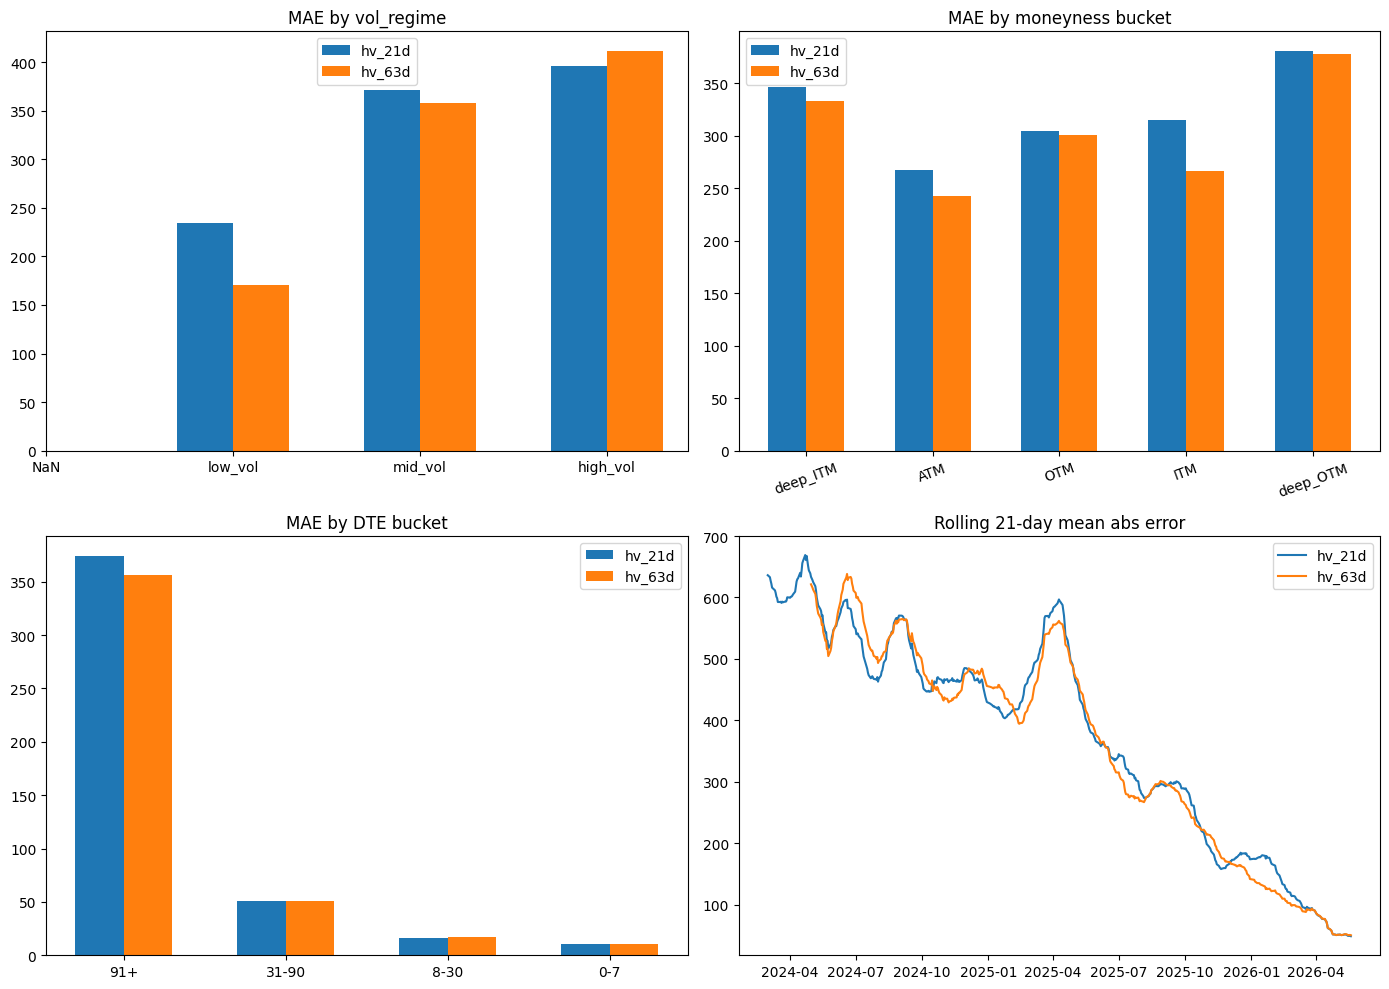

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vol_plot = vol_regime_metrics.dropna(subset=['slice_value']).copy()
x = np.arange(len(vol_plot))
axes[0, 0].bar(x - 0.15, vol_plot['MAE_hv_21d'], width=0.3, label='hv_21d')
axes[0, 0].bar(x + 0.15, vol_plot['MAE_hv_63d'], width=0.3, label='hv_63d')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(vol_plot['slice_value'].astype(str).tolist())
axes[0, 0].set_title('MAE by vol_regime')
axes[0, 0].legend()

money_plot = moneyness_metrics.dropna(subset=['slice_value']).copy()
x = np.arange(len(money_plot))
axes[0, 1].bar(x - 0.15, money_plot['MAE_hv_21d'], width=0.3, label='hv_21d')
axes[0, 1].bar(x + 0.15, money_plot['MAE_hv_63d'], width=0.3, label='hv_63d')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(money_plot['slice_value'].astype(str).tolist(), rotation=20)
axes[0, 1].set_title('MAE by moneyness bucket')
axes[0, 1].legend()

dte_plot = dte_metrics.dropna(subset=['slice_value']).copy()
x = np.arange(len(dte_plot))
axes[1, 0].bar(x - 0.15, dte_plot['MAE_hv_21d'], width=0.3, label='hv_21d')
axes[1, 0].bar(x + 0.15, dte_plot['MAE_hv_63d'], width=0.3, label='hv_63d')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(dte_plot['slice_value'].astype(str).tolist())
axes[1, 0].set_title('MAE by DTE bucket')
axes[1, 0].legend()

rolling = (
    df.groupby('TRADEDATE')[['abs_error_hv_21d', 'abs_error_hv_63d']]
    .mean()
    .rolling(21)
    .mean()
    .reset_index()
)
axes[1, 1].plot(rolling['TRADEDATE'], rolling['abs_error_hv_21d'], label='hv_21d')
axes[1, 1].plot(rolling['TRADEDATE'], rolling['abs_error_hv_63d'], label='hv_63d')
axes[1, 1].set_title('Rolling 21-day mean abs error')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Final conclusion

- Среди двух historical-volatility baseline вариантов `hv_63d` выглядит немного сильнее, чем `hv_21d`: его средние ошибки ниже почти по всем общим метрикам.
- Ошибки baseline возрастают в `high_vol` regime, то есть простая historical volatility особенно слабо работает в турбулентные периоды.
- Наиболее сложные состояния рынка для baseline - это комбинации высокой волатильности и выраженного тренда, особенно `high_vol_up`, а также `high_vol_down` и `mid_vol_down`.
- По moneyness baseline относительно лучше работает ближе к `ATM`, а хуже - на хвостах (`deep_OTM`, `deep_ITM`).
- По maturity baseline заметно хуже на длинных опционах (`91+` дней), чем на коротких контрактах.
- Итоговый вывод: `Black-76 + historical volatility` подходит как минимальный benchmark, но этого явно недостаточно как финальной модели рынка.
- Логичный следующий шаг - проверить более адаптивный volatility input: сначала `GARCH volatility forecast`, а затем по возможности сравнить всё это с implied-vol based benchmark.

## Save outputs

Сохраним сводные таблицы отдельно, чтобы потом можно было использовать их в тексте курсовой, в презентации или в следующих notebooks.

In [10]:
summary_frames = {
    'overall': overall_metrics,
    'vol_regime': vol_regime_metrics,
    'trend_regime': trend_regime_metrics,
    'regime_label': regime_label_metrics,
    'moneyness_bucket': moneyness_metrics,
    'dte_bucket': dte_metrics,
}

summary_rows = []
for table_name, table in summary_frames.items():
    tmp = table.copy()
    tmp['table_name'] = table_name
    summary_rows.append(tmp)

summary_csv = pd.concat(summary_rows, ignore_index=True, sort=False)

xlsx_path = results_dir / 'error_analysis_tables.xlsx'
csv_path = results_dir / 'error_analysis_summary.csv'

with pd.ExcelWriter(xlsx_path) as writer:
    for sheet_name, table in summary_frames.items():
        table.to_excel(writer, sheet_name=sheet_name[:31], index=False)

summary_csv.to_csv(csv_path, index=False)

print('Saved:', xlsx_path)
print('Saved:', csv_path)

Saved: /Users/maria/Desktop/Code/HSE/COURSEBOOK/results/error_analysis_tables.xlsx
Saved: /Users/maria/Desktop/Code/HSE/COURSEBOOK/results/error_analysis_summary.csv
